In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read the data from the CSV file data.csv

# data = pd.read_csv('data.csv')
# load from tar.gz
data = pd.read_csv('lora_request_trace.tar.gz', compression='gzip')
data

,gmt_create,gmt_modified,predict_type,predict_status,exec_time,exec_time_seconds,groupId,prompt_length,negative_prompt_length,num_images_per_prompt,num_inference_steps,checkpoint_model_version_id,num_lora
0,2025-02-01 09:57:50,2025-02-01 09:58:22,TXT_2_IMG,SUCCEED,0 days 00:00:32,32.0,G0000,63.0,26.0,1.0,30.0,M0000,0
1,2025-02-01 11:16:14,2025-02-01 11:16:57,TXT_2_IMG,SUCCEED,0 days 00:00:43,43.0,G0001,93.0,NaN,1.0,40.0,M0001,0
2,2025-02-01 11:17:06,2025-02-01 11:17:42,TXT_2_IMG,SUCCEED,0 days 00:00:36,36.0,G0001,93.0,NaN,8.0,40.0,M0001,0
3,2025-02-01 11:17:16,2025-02-01 11:18:09,IMG_2_IMG,SUCCEED,0 days 00:00:53,53.0,G0001,93.0,NaN,8.0,40.0,M0001,0
4,2025-02-01 11:21:34,2025-02-01 11:22:25,IMG_2_IMG,SUCCEED,0 days 00:00:51,51.0,G0001,79.0,NaN,8.0,40.0,M0001,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26818,2025-02-24 10:33:24,2025-02-24 10:33:48,IMG_2_IMG,SUCCEED,0 days 00:00:24,24.0,G3974,16.0,26.0,1.0,30.0,M0004,1
26819,2025-02-24 10:33:25,2025-02-24 10:34:09,TXT_2_IMG,SUCCEED,0 days 00:00:44,44.0,G0287,7.0,NaN,4.0,30.0,M0001,1
26820,2025-02-24 10:33:45,2025-02-24 10:34:00,TXT_2_IMG,SUCCEED,0 days 00:00:15,15.0,G2054,47.0,26.0,1.0,30.0,M0010,0
26821,2025-02-24 10:33:46,2025-02-24 10:34:18,TXT_2_IMG,PROCESSING,0 days 00:00:32,32.0,G0263,45.0,NaN,4.0,30.0,M0003,1


predict_type
IMG_2_IMG     0.066481
INPAINTING    0.005633
TXT_2_IMG     0.737039
dtype: float64


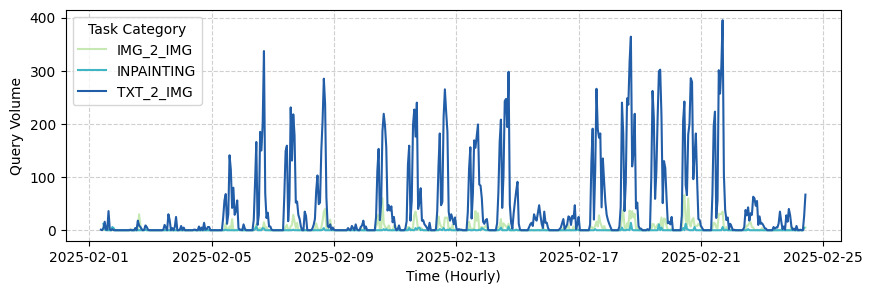

In [3]:
data_online = data.copy()
data_online['gmt_create'] = pd.to_datetime(data_online['gmt_create'])

qps = data_online.groupby('predict_type').apply(
    lambda grp: grp.set_index('gmt_create').resample('Min').size().mean()
)
print(qps)

plot_data = data_online

qps_hourly = (
    plot_data.groupby('predict_type')
    .resample('H', on='gmt_create')
    .size()
    .reset_index(name='count')
)
fig, ax = plt.subplots(figsize=(10, 3))
# Plot the time series with hue based on predict_type
sns.lineplot(x='gmt_create', y='count', hue='predict_type', data=qps_hourly, ax=ax,palette='YlGnBu')
ax.legend(loc='upper left', ncol=1, title='Task Category')
plt.xlabel('Time (Hourly)')
plt.ylabel('Query Volume')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# fig.savefig('qps_hourly.pdf', bbox_inches='tight', dpi=120)



/tmp/ipykernel_1820367/1190207994.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='predict_type', y='exec_time_seconds', data=data_online, ax=ax, hue='num_lora', ci=None, palette='YlGnBu', alpha=0.9)


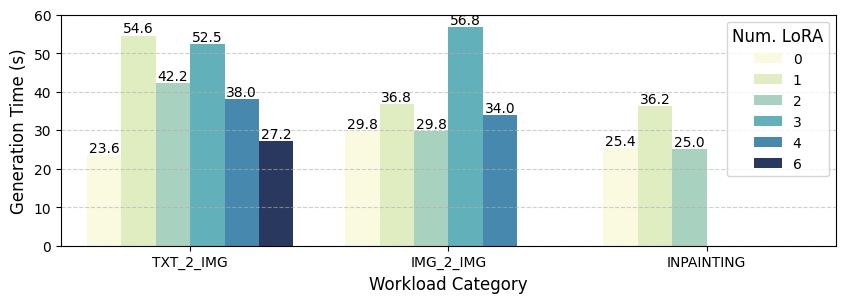

In [4]:
fig, ax = plt.subplots(figsize=(10, 3))

sns.barplot(x='predict_type', y='exec_time_seconds', data=data_online, ax=ax, hue='num_lora', ci=None, palette='YlGnBu', alpha=0.9)

ax.set_ylabel("Generation Time (s)", fontsize=12)
ax.set_xlabel("Workload Category", fontsize=12)
ax.legend(title='Num. LoRA', title_fontsize='12', fontsize='10', loc='upper right')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, color='black')
ax.grid(axis='y', linestyle='--', alpha=0.6)

ax.set_ylim(0, 60)
plt.show()
# fig.savefig('..predict_type_exectime.pdf')